In [ ]:
# Conectando STAC - Colab
!pip install pystac-client
!pip install matplotlib
!pip install folium
!pip install rasterio
!pip install numpy
!pip install geopandas
!pip install shapely
!pip install pyproj

In [ ]:
# Bibliotecas
import pystac_client
import matplotlib.pyplot as plt
import folium
import rasterio
import numpy as np
import geopandas as gpd
import shapely
import pyproj

In [ ]:
# Conectando
service = pystac_client.Client.open('https://data.inpe.br/bdc/stac/v1/')
for collection in service.get_collections():
    print(collection)

<CollectionClient id=AMZ1-WFI-L4-DN-1>
<CollectionClient id=mosaic-cbers4a-paraiba-3m-1>
<CollectionClient id=mosaic-landsat-sp-6m-1>
<CollectionClient id=CB4-MUX-L4-SR-1>
<CollectionClient id=mosaic-s2-paraiba-3m-1>
<CollectionClient id=MODISA-OCSMART-POC-DAILY-1>
<CollectionClient id=mosaic-s2-yanomami_territory-6m-1>
<CollectionClient id=MODISA-OCSMART-RRS-MONTHLY-1>
<CollectionClient id=s3-olci-rrs-water-1>
<CollectionClient id=CB4-WFI-L2-DN-1>
<CollectionClient id=AMZ1-WFI-L2-DN-1>
<CollectionClient id=CB4-PAN10M-L2-DN-1>
<CollectionClient id=CB4A-WFI-L4-SR-1>
<CollectionClient id=GOES-GL-DSWRF-Daily-1>
<CollectionClient id=CB4-MUX-L4-DN-1>
<CollectionClient id=mosaic-landsat-amazon-3m-1>
<CollectionClient id=mosaic-s2-amazon-3m-1>
<CollectionClient id=S2-16D-2>
<CollectionClient id=S2_L2A-1>
<CollectionClient id=landsat-tsirf-bimonthly-1>
<CollectionClient id=CB4-WFI-L4-DN-1>
<CollectionClient id=mod13q1-6.1>
<CollectionClient id=mosaic-landsat-brazil-6m-1>
<CollectionClient id=C

In [ ]:
collection = service.get_collection('S2-16D-2')
collection

<CollectionClient id=S2-16D-2>

In [ ]:
item_search = service.search(bbox=(-37.916053,-9.568818,-37.748511,-9.448545),
                             datetime='2018-08-01/2019-07-31',
                             collections=['S2-16D-2'],
                             query={"eo:cloud_cover": {"lt": 20}})
item_search
item_search.matched()

35

In [ ]:
#for item in item_search.items():
   # print(item)

items = list(item_search.items())
item = items[0]  # ou melhor critério (ex: menor cloud cover)
assets = item.assets

In [ ]:
assets = item.assets
for k in assets.keys():
    print(k)

B01
B02
B03
B04
B05
B06
B07
B08
B09
B11
B12
B8A
EVI
NBR
SCL
NDVI
CLEAROB
TOTALOB
thumbnail
PROVENANCE


In [ ]:
# Pegando EVI
evi_asset = assets['EVI']
evi_asset

<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_EVI.tif>

In [ ]:
# NDVI
ndvi_asset = assets['NDVI']
ndvi_asset

<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_NDVI.tif>

In [ ]:
for asset in assets.values():
    print(asset)

<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_B01.tif>
<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_B02.tif>
<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_B03.tif>
<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_B04.tif>
<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_B05.tif>
<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_B06.tif>
<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_B07.tif>
<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_B08.tif>
<Asset href=https://data.inpe.br/bdc/data/s2-16d/v2/039/016/2019/07/12/S2-16D_V2_039016_20190712_B09.tif>
<Asset href=https://data.inpe.br/bdc/data/s2-1

In [ ]:
# Visualizando o EVI e NDVI
import rasterio as rio
with rio.open(assets['EVI'].href) as evi_ds:
    evi = evi_ds.read(1)

In [ ]:
evi

array([[6350, 6399, 6023, ..., 3271, 2909, 2903],
       [6373, 6193, 5367, ..., 3194, 3464, 3171],
       [5359, 5464, 4992, ..., 4208, 4647, 4038],
       ...,
       [8469, 9123, 9056, ..., 6965, 6933, 4734],
       [8199, 8780, 8957, ..., 7017, 7158, 4373],
       [8110, 8378, 8935, ..., 6924, 7121, 4363]], dtype=int16)

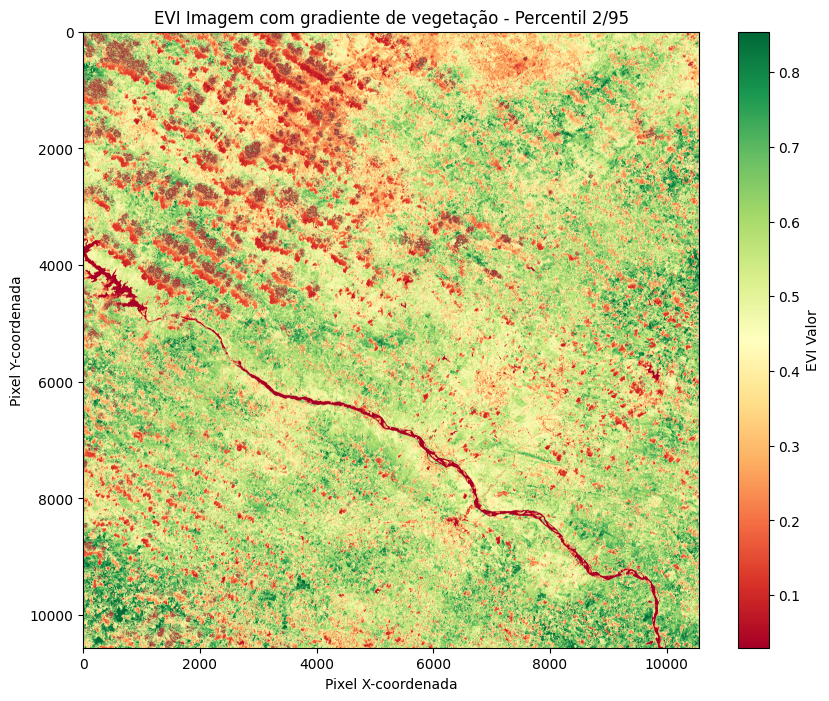

In [ ]:
from matplotlib import pyplot as plt

# Normalizando evi de 0-1 valor
evi_normalizado = evi / 10000.0

plt.figure(figsize=(10, 8)) # figura larga melhor visualização
plt.imshow(evi_normalizado, cmap='RdYlGn', vmin = np.percentile(evi_normalizado, 2),
vmax = np.percentile(evi_normalizado, 98))
plt.colorbar(label='EVI Valor')
plt.title('EVI Imagem com gradiente de vegetação - Percentil 2/95')
plt.xlabel('Pixel X-coordenada')
plt.ylabel('Pixel Y-coordenada')
plt.savefig('evi.png')
plt.show()

In [ ]:
# Calculando media e desvio padrão
mean_evi = np.mean(evi_normalizado)
std_dev_evi = np.std(evi_normalizado)

print(f"Média do EVI Normalizado: {mean_evi:.4f}")
print(f"Desvio Padrão do EVI Normalizado: {std_dev_evi:.4f}")

Média do EVI Normalizado: 0.4690
Desvio Padrão do EVI Normalizado: 0.2992


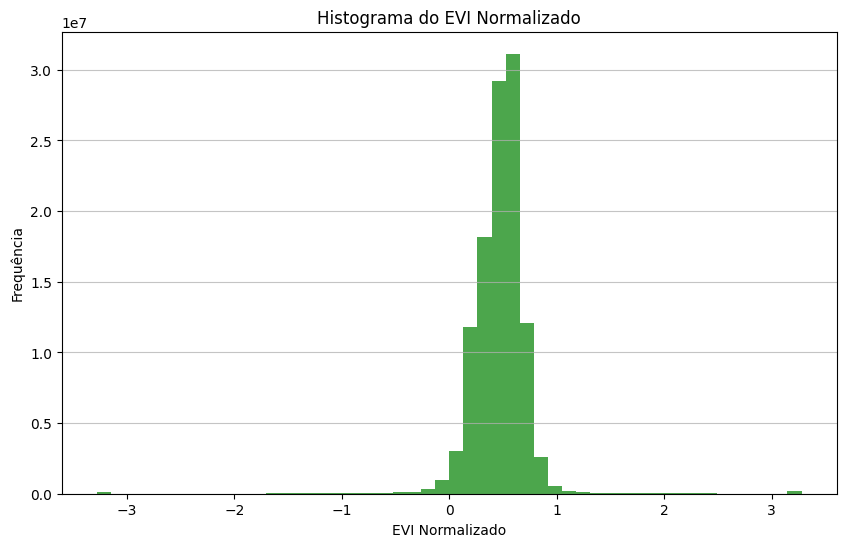

In [ ]:
# Histograma
plt.figure(figsize=(10, 6))
plt.hist(evi_normalizado.flatten(), bins=50, color='green', alpha=0.7)
plt.title('Histograma do EVI Normalizado')
plt.xlabel('EVI Normalizado')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# Visualizando o NDVI
import rasterio as rio
with rio.open(assets['NDVI'].href) as ndvi_ds:
    ndvi = ndvi_ds.read(1)

In [ ]:
ndvi

array([[2598, 2640, 2672, ..., 1144,  896,  852],
       [2708, 2714, 2622, ..., 1101,  939,  844],
       [2560, 2641, 2522, ..., 1235, 1087,  930],
       ...,
       [8547, 8629, 8529, ..., 8807, 8695, 5182],
       [8591, 8607, 8538, ..., 8817, 8877, 4900],
       [8653, 8616, 8629, ..., 8660, 8879, 4869]], dtype=int16)

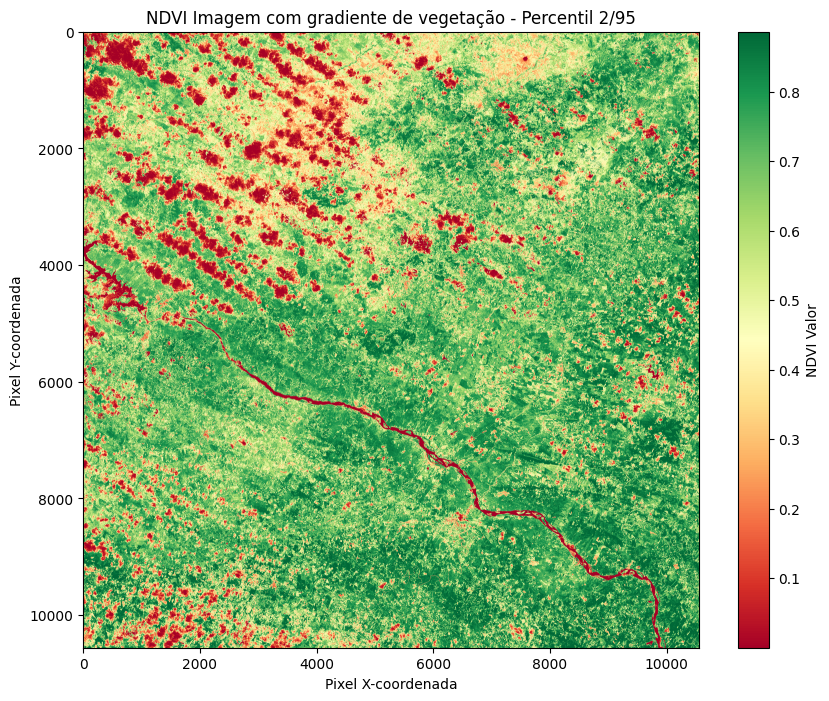

In [ ]:
# Normalizando NDVI de 0-1 valor
ndvi_normalizado = ndvi / 10000.0

plt.figure(figsize=(10, 8)) # figura larga melhor visualização
plt.imshow(ndvi_normalizado, cmap='RdYlGn', vmin = np.percentile(ndvi_normalizado, 2),
vmax = np.percentile(ndvi_normalizado, 98))
plt.colorbar(label='NDVI Valor')
plt.title('NDVI Imagem com gradiente de vegetação - Percentil 2/95')
plt.xlabel('Pixel X-coordenada')
plt.ylabel('Pixel Y-coordenada')
plt.savefig('ndvi.png')
plt.show()

In [ ]:
# Calculando media e desvio padrão
mean_ndvi = np.mean(ndvi_normalizado)
std_dev_ndvi = np.std(ndvi_normalizado)

print(f"Média do NDVI Normalizado: {mean_ndvi:.4f}")
print(f"Desvio Padrão do NDVI Normalizado: {std_dev_ndvi:.4f}")

Média do NDVI Normalizado: 0.5994
Desvio Padrão do NDVI Normalizado: 0.2432


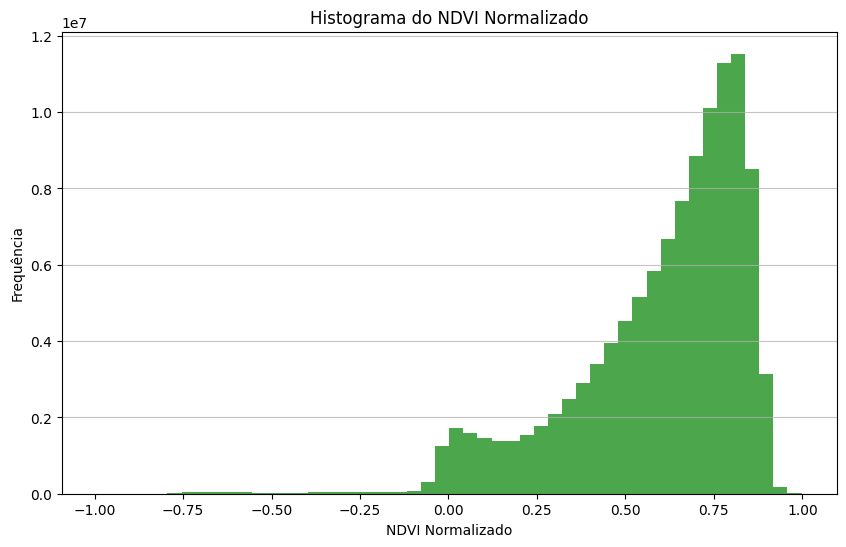

In [ ]:
# Histograma
plt.figure(figsize=(10, 6))
plt.hist(ndvi_normalizado.flatten(), bins=50, color='green', alpha=0.7)
plt.title('Histograma do NDVI Normalizado')
plt.xlabel('NDVI Normalizado')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
plt.figure(figsize=(20, 8)) # Ajuste o tamanho da figura para melhor visualização

# Subplot para EVI
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
plt.imshow(evi_normalizado, cmap='RdYlGn', vmin=np.percentile(evi_normalizado, 2), vmax=np.percentile(evi_normalizado, 98))
plt.colorbar(label='EVI Valor')
plt.title('EVI Imagem (Percentil 2/98)')
plt.xlabel('Pixel X-coordenada')
plt.ylabel('Pixel Y-coordenada')

# Subplot para NDVI
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
plt.imshow(ndvi_normalizado, cmap='RdYlGn', vmin=np.percentile(ndvi_normalizado, 2), vmax=np.percentile(ndvi_normalizado, 98))
plt.colorbar(label='NDVI Valor')
plt.title('NDVI Imagem (Percentil 2/98)')
plt.xlabel('Pixel X-coordenada')
plt.ylabel('Pixel Y-coordenada')

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.savefig('evi_ndvi_lado_a_lado.png')
plt.show()